# Respostas aos revisores — análises complementares

Notebook complementar ao pipeline de `cross-lingual-syntactic-attention`. Cada seção
implementa uma análise que responde a um questionamento específico dos pareceres.

| Seção | Crítica do revisor | O que resolve |
|---|---|---|
| 1 | **Invariância de permutação de cabeças** (2 revisores) | Recalcula o ρ_micro casando cabeças entre modelos (Hungarian) em vez de comparar por índice absoluto |
| 2 | Impacto da direção `head_to_dep` vs `dep_to_head` (aBFE) | Recomputa todas as métricas na direção oposta a partir do mesmo CSV |
| 3 | Identificar as cabeças *funcionalmente relevantes* (via Voita) | Sobreposição (Jaccard) das top-k cabeças e correlação restrita a elas |
| 4 | Matrizes de correlação simétricas redundantes (yvqE) | Plota apenas o triângulo |
| 5 | Treebank pequeno do galego + fallback train→dev (todos) | Quantifica sentenças/arcos por relação e sinaliza o fallback |
| 6 | Robustez corpus vs. modelo (aBFE) | Amostragem aleatória com *seed* + runners para (a) 2 modelos da mesma língua e (b) 2 corpora no mesmo modelo |
| 7 | Objetivo da Seção 4.5; fazer análise monolíngue primeiro (aBFE) | Concentração intra-modelo por relação antes do cruzamento |
| 8 | Método de agregação na 3.4 (aBFE) | Documenta/verifica que a agregação é média aritmética |

**Seções 1–5, 7 e 8** rodam direto do CSV agregado que seu pipeline já produz.
**Seção 6** exige `torch`/`transformers` e os treebanks (rode no seu ambiente).


## 0. Setup e carregamento

Aponte `CSV_PATH` para o seu CSV agregado (`romanic_attention_generalization_all_splits.csv`).
Se o arquivo não existir, o notebook gera um **CSV sintético** com a mesma estrutura
(7 línguas, 4 relações, 12×12, ambas as direções) para que tudo seja executável de imediato.
O sintético planta, de propósito, um par com padrão **permutado** para demonstrar o efeito da Seção 1.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from itertools import combinations
from scipy.optimize import linear_sum_assignment
from pathlib import Path

CSV_PATH   = "/home/ricardo/doutorado/SEPLN - Linguas_Romanicas/git/cross-lingual-syntactic-attention-main (2)/data/attention_all_splits.csv"  # ajuste aqui
DIRECTION  = "head_to_dep"     # direção principal do artigo
SPLIT      = "test"              # ex.: "test"; None = usa tudo que houver
MODEL_FAM  = "mono"            # família de modelos analisada no artigo
L = H = 12                     # 12 camadas x 12 cabeças (BERT-base)

REQUIRED = {"lang","deprel","layer","head","direction","mean_attention","n_arcs"}

def make_synthetic(seed=0):
    rng = np.random.default_rng(seed)
    langs=["pt","gl","es","fr","it","ro","de"]; deps=["nsubj","obj","case","amod"]
    rows=[]
    for dep in deps:
        pt=rng.random((L,H)); perm=rng.permutation(H)
        pats={"pt":pt,
              "gl":pt+0.02*rng.random((L,H)),          # pt~gl: alto por indice
              "es":pt[:,perm]+0.02*rng.random((L,H))}  # copia PERMUTADA de pt
        for lg in ["fr","it","ro","de"]: pats[lg]=rng.random((L,H))
        for lg,M in pats.items():
            n=int(rng.integers(150,1100))
            for l in range(L):
                for h in range(H):
                    for d in ("head_to_dep","dep_to_head"):
                        rows.append(dict(lang=lg,lang_group=("controle" if lg=="de" else "romanico"),
                            model_id=f"m_{lg}",model_family="mono",treebank=f"UD_{lg}",split="test",
                            deprel=dep,layer=l+1,head=h+1,direction=d,
                            mean_attention=float(M[l,h] if d=="head_to_dep" else M[l,h]*0.8),
                            std_attention=0.01,n_arcs=n))
    return pd.DataFrame(rows)

if Path(CSV_PATH).exists():
    df = pd.read_csv(CSV_PATH); print("CSV real carregado:", CSV_PATH)
else:
    df = make_synthetic(); print("[AVISO] CSV nao encontrado -> usando dados SINTETICOS de demonstracao.")

miss = REQUIRED - set(df.columns)
assert not miss, f"Colunas faltando no CSV: {sorted(miss)}"

# filtros padrao
d = df[df["direction"]==DIRECTION].copy()
if SPLIT and "split" in d.columns: d = d[d["split"]==SPLIT]
if MODEL_FAM and "model_family" in d.columns and (d["model_family"]==MODEL_FAM).any():
    d = d[d["model_family"]==MODEL_FAM]
DEPS  = sorted(d["deprel"].unique().tolist())
LANGS = sorted(d["lang"].unique().tolist())
print("Relacoes:", DEPS); print("Linguas:", LANGS); print("Linhas apos filtro:", len(d))

CSV real carregado: /home/ricardo/doutorado/SEPLN - Linguas_Romanicas/git/cross-lingual-syntactic-attention-main (2)/data/attention_all_splits.csv
Relacoes: ['amod', 'case', 'nsubj', 'obj']
Linguas: ['de', 'es', 'fr', 'gl', 'it', 'pt', 'ro']
Linhas apos filtro: 4032


### Funções auxiliares (vetor 144, matriz 12×12, Spearman, pesos)

In [2]:
def spearman(a, b):
    a=np.asarray(a,float); b=np.asarray(b,float)
    ra=pd.Series(a).rank(method="average").to_numpy()
    rb=pd.Series(b).rank(method="average").to_numpy()
    if np.std(ra)==0 or np.std(rb)==0: return np.nan
    return float(np.corrcoef(ra,rb)[0,1])

def mat12(frame, lang, dep):
    '''Matriz [L,H] de mean_attention para uma lingua/relacao.'''
    M=np.zeros((L,H)); s=frame[(frame["lang"]==lang)&(frame["deprel"]==dep)]
    for _,r in s.iterrows():
        M[int(r["layer"])-1, int(r["head"])-1] = float(r["mean_attention"])
    return M

def arcs(frame, lang, dep):
    s=frame[(frame["lang"]==lang)&(frame["deprel"]==dep)]
    return float(s["n_arcs"].sum())

def signature_tensor(frame, lang):
    '''[L,H,n_dep] assinatura de cada cabeca atraves das relacoes (para o matching).'''
    T=np.zeros((L,H,len(DEPS)))
    for di,dep in enumerate(DEPS): T[:,:,di]=mat12(frame,lang,dep)
    return T

## 1. Head matching (responde à invariância de permutação) — **prioridade máxima**

> *"Comparing heads by absolute index across independently trained models ignores permutation
> invariance" / "A head-matching step per layer would be a fairer test of micro-level generalization
> (assignment on the 12×12 head-correlation matrix)."*

A cabeça *i* do modelo A **não** corresponde à cabeça *i* do modelo B em modelos treinados de forma
independente. O ρ_micro atual pode estar artificialmente baixo só por isso. Aqui recomputamos o
ρ_micro **casando as cabeças** dentro de cada camada com o algoritmo húngaro
(`scipy.optimize.linear_sum_assignment`), em três variantes:

- **`index`** — método atual do artigo (alinhamento por índice).
- **`matched_joint`** — uma permutação por camada, estimada pela assinatura da cabeça em **todas** as relações; recomputa o ρ por relação sobre as cabeças casadas.
- **`matched_loo`** — *leave-one-out*: casa as cabeças usando as **demais** relações (exclui a relação avaliada). Evita circularidade e é o número mais defensável para o texto.

Não exige reextrair atenção: tudo sai do CSV agregado.

In [3]:
def layer_permutations(TA, TB, keep_dims):
    '''Para cada camada, casa as H cabecas de B as de A pela distancia euclidiana
    das assinaturas (somente nas dimensoes 'keep_dims').'''
    perms=[]
    for l in range(L):
        A=TA[l][:,keep_dims]; B=TB[l][:,keep_dims]
        C=np.linalg.norm(A[:,None,:]-B[None,:,:], axis=2)   # custo [H,H]
        _, ci = linear_sum_assignment(C)
        perms.append(ci)
    return perms

def micro_pair(frame, la, lb, mode="matched_loo"):
    '''Retorna dict {dep: rho_micro} para o par (la,lb) sob o modo escolhido.'''
    TA=signature_tensor(frame,la); TB=signature_tensor(frame,lb); out={}
    for di,dep in enumerate(DEPS):
        a=TA[:,:,di]
        if mode=="index":
            b=TB[:,:,di]
        else:
            keep = list(range(len(DEPS))) if mode=="matched_joint" \
                   else [j for j in range(len(DEPS)) if j!=di]
            perms=layer_permutations(TA,TB,keep)
            b=np.zeros((L,H))
            for l in range(L): b[l]=TB[l,perms[l],di]
        out[dep]=spearman(a.flatten(), b.flatten())
    return out

def micro_weighted_mean(frame, mode):
    '''Media ponderada por min(n_arcs) entre pares de linguas, por relacao (igual ao artigo).'''
    rows=[]
    for dep in DEPS:
        num=den=0.0
        for la,lb in combinations(LANGS,2):
            r=micro_pair(frame,la,lb,mode)[dep]
            w=min(arcs(frame,la,dep), arcs(frame,lb,dep))
            if not np.isnan(r): num+=r*w; den+=w
        rows.append({"deprel":dep, f"rho_micro_{mode}": (num/den if den>0 else np.nan)})
    return pd.DataFrame(rows)

tbl = micro_weighted_mean(d,"index")
for mode in ["matched_joint","matched_loo"]:
    tbl = tbl.merge(micro_weighted_mean(d,mode), on="deprel")
tbl = tbl.round(3)
print(tbl.to_string(index=False))

deprel  rho_micro_index  rho_micro_matched_joint  rho_micro_matched_loo
  amod            0.090                    0.676                  0.485
  case            0.057                    0.566                  0.323
 nsubj            0.166                    0.683                  0.492
   obj            0.136                    0.730                  0.579


**Como ler:** se `matched_loo` ≫ `index`, parte da "dissociação micro/macro" era artefato de
permutação e a conclusão precisa ser reescrita. Se `matched_loo` ≈ `index` (continua baixo), a
dissociação é genuína e o artigo fica **blindado** contra essa crítica — em ambos os casos você ganha.

### 1b. Detalhe por par de línguas (foco em pt–gl e nos controles)

In [4]:
def pair_table(frame, mode):
    recs=[]
    for la,lb in combinations(LANGS,2):
        r=micro_pair(frame,la,lb,mode)
        recs.append({"par":f"{la}-{lb}", **{k:round(v,3) for k,v in r.items()}})
    return pd.DataFrame(recs)

idx_pairs = pair_table(d,"index")
loo_pairs = pair_table(d,"matched_loo")
print("=== index (atual) ===");      print(idx_pairs.to_string(index=False))
print("\n=== matched_loo (proposto) ==="); print(loo_pairs.to_string(index=False))

=== index (atual) ===
  par   amod   case  nsubj    obj
de-es  0.078  0.046  0.203  0.124
de-fr  0.025  0.006  0.116  0.054
de-gl  0.036  0.203  0.133  0.014
de-it  0.046 -0.048  0.038 -0.087
de-pt -0.015  0.170  0.100 -0.033
de-ro  0.191  0.011  0.172  0.093
es-fr -0.112 -0.130  0.008 -0.014
es-gl  0.037 -0.039  0.095  0.183
es-it  0.043  0.109  0.029  0.059
es-pt  0.040 -0.034  0.074  0.169
es-ro  0.032 -0.081  0.263  0.141
fr-gl -0.034  0.029  0.159  0.117
fr-it  0.015 -0.126  0.061  0.020
fr-pt -0.020  0.042  0.112  0.049
fr-ro  0.030  0.107  0.162  0.047
gl-it  0.166  0.041  0.146  0.203
gl-pt  0.886  0.914  0.880  0.909
gl-ro  0.140  0.127  0.267  0.157
it-pt  0.205  0.101  0.194  0.245
it-ro  0.015 -0.133  0.188  0.123
pt-ro  0.078  0.080  0.204  0.114

=== matched_loo (proposto) ===
  par  amod  case  nsubj   obj
de-es 0.335 0.324  0.468 0.334
de-fr 0.307 0.193  0.396 0.405
de-gl 0.279 0.286  0.397 0.433
de-it 0.341 0.174  0.514 0.450
de-pt 0.288 0.348  0.450 0.450
de-ro 0.212 

## 2. Robustez de direção: `head_to_dep` vs `dep_to_head`

> *"What is the impact of choosing one of the two directions in the analysis?"*

O `run_ud_attention_eval.py` já grava **as duas direções**. Aqui recomputamos o ρ_micro (média
ponderada) nas duas, sem reextrair nada, para reportar como robustez.

In [5]:
def micro_by_direction(direction, mode="index"):
    sub = df[df["direction"]==direction].copy()
    if SPLIT and "split" in sub.columns: sub=sub[sub["split"]==SPLIT]
    if MODEL_FAM and "model_family" in sub.columns and (sub["model_family"]==MODEL_FAM).any():
        sub=sub[sub["model_family"]==MODEL_FAM]
    # reusa as funcoes globais assumindo o mesmo conjunto DEPS/LANGS
    rows=[]
    for dep in DEPS:
        num=den=0.0
        for la,lb in combinations(LANGS,2):
            r=micro_pair(sub,la,lb,mode)[dep]
            w=min(arcs(sub,la,dep), arcs(sub,lb,dep))
            if not np.isnan(r): num+=r*w; den+=w
        rows.append({"deprel":dep, direction:(num/den if den>0 else np.nan)})
    return pd.DataFrame(rows)

dirs = sorted(df["direction"].unique().tolist())
cmp = None
for dr in dirs:
    t=micro_by_direction(dr,"index")
    cmp = t if cmp is None else cmp.merge(t,on="deprel")
print("rho_micro (index) por direcao:")
print(cmp.round(3).to_string(index=False))

rho_micro (index) por direcao:
deprel  dep_to_head  head_to_dep
  amod        0.075        0.090
  case        0.111        0.057
 nsubj        0.142        0.166
   obj        0.111        0.136


## 3. Cabeças funcionalmente relevantes (responde à observação via Voita et al.)

> *"Only a subset of heads contributes substantially... identify those relevant heads for each
> syntactic function and quantify their correlation."*

Em vez de correlacionar as 144 posições, isolamos as **top-k** cabeças que mais concentram atenção
em cada relação/modelo e medimos: (i) **Jaccard** da sobreposição entre línguas e (ii) ρ_micro
**restrito à união** das top-k. Tudo a partir do CSV.

In [6]:
def topk_heads(frame, lang, dep, k=10):
    M=mat12(frame,lang,dep).flatten()
    return set(np.argsort(M)[::-1][:k].tolist())

def jaccard_topk(frame, dep, k=10):
    recs=[]
    for la,lb in combinations(LANGS,2):
        A=topk_heads(frame,la,dep,k); B=topk_heads(frame,lb,dep,k)
        j = len(A&B)/len(A|B) if (A|B) else np.nan
        recs.append({"par":f"{la}-{lb}", dep:round(j,3)})
    return pd.DataFrame(recs)

def micro_restricted_topk(frame, dep, k=10):
    ''' rho_micro calculado apenas na uniao das top-k cabecas de cada par.'''
    recs=[]
    for la,lb in combinations(LANGS,2):
        A=topk_heads(frame,la,dep,k); B=topk_heads(frame,lb,dep,k); U=sorted(A|B)
        va=mat12(frame,la,dep).flatten()[U]; vb=mat12(frame,lb,dep).flatten()[U]
        recs.append({"par":f"{la}-{lb}", dep:round(spearman(va,vb),3)})
    return pd.DataFrame(recs)

K=10
print(f"Jaccard das top-{K} cabecas (por par):")
jac=jaccard_topk(d,DEPS[0],K)
for dep in DEPS[1:]: jac=jac.merge(jaccard_topk(d,dep,K),on="par")
print(jac.to_string(index=False))

print(f"\nrho_micro restrito a uniao das top-{K} cabecas:")
res=micro_restricted_topk(d,DEPS[0],K)
for dep in DEPS[1:]: res=res.merge(micro_restricted_topk(d,dep,K),on="par")
print(res.to_string(index=False))

Jaccard das top-10 cabecas (por par):
  par  amod  case  nsubj   obj
de-es 0.000 0.053  0.000 0.000
de-fr 0.111 0.053  0.111 0.000
de-gl 0.053 0.000  0.111 0.053
de-it 0.053 0.111  0.000 0.000
de-pt 0.053 0.000  0.111 0.053
de-ro 0.000 0.000  0.053 0.053
es-fr 0.000 0.053  0.000 0.111
es-gl 0.000 0.000  0.000 0.000
es-it 0.000 0.053  0.053 0.053
es-pt 0.111 0.000  0.000 0.053
es-ro 0.000 0.000  0.053 0.111
fr-gl 0.053 0.053  0.176 0.000
fr-it 0.053 0.053  0.053 0.000
fr-pt 0.000 0.053  0.176 0.053
fr-ro 0.053 0.053  0.111 0.053
gl-it 0.111 0.053  0.000 0.111
gl-pt 0.538 0.818  0.667 0.818
gl-ro 0.053 0.053  0.111 0.000
it-pt 0.176 0.053  0.000 0.111
it-ro 0.111 0.111  0.111 0.053
pt-ro 0.111 0.053  0.053 0.053

rho_micro restrito a uniao das top-10 cabecas:
  par   amod   case  nsubj    obj
de-es -0.832 -0.647 -0.731 -0.773
de-fr -0.709 -0.749 -0.587 -0.780
de-gl -0.505 -0.823 -0.626 -0.514
de-it -0.565 -0.459 -0.705 -0.654
de-pt -0.530 -0.805 -0.628 -0.551
de-ro -0.729 -0.786 -0.737 -

## 4. Matrizes de correlação triangulares (responde a yvqE)

> *"The correlation matrices are symmetric... values should only appear once, by an upper or lower
> triangular portion."*

Reconstruímos a matriz de correlação entre línguas (por índice) e plotamos só o triângulo inferior.

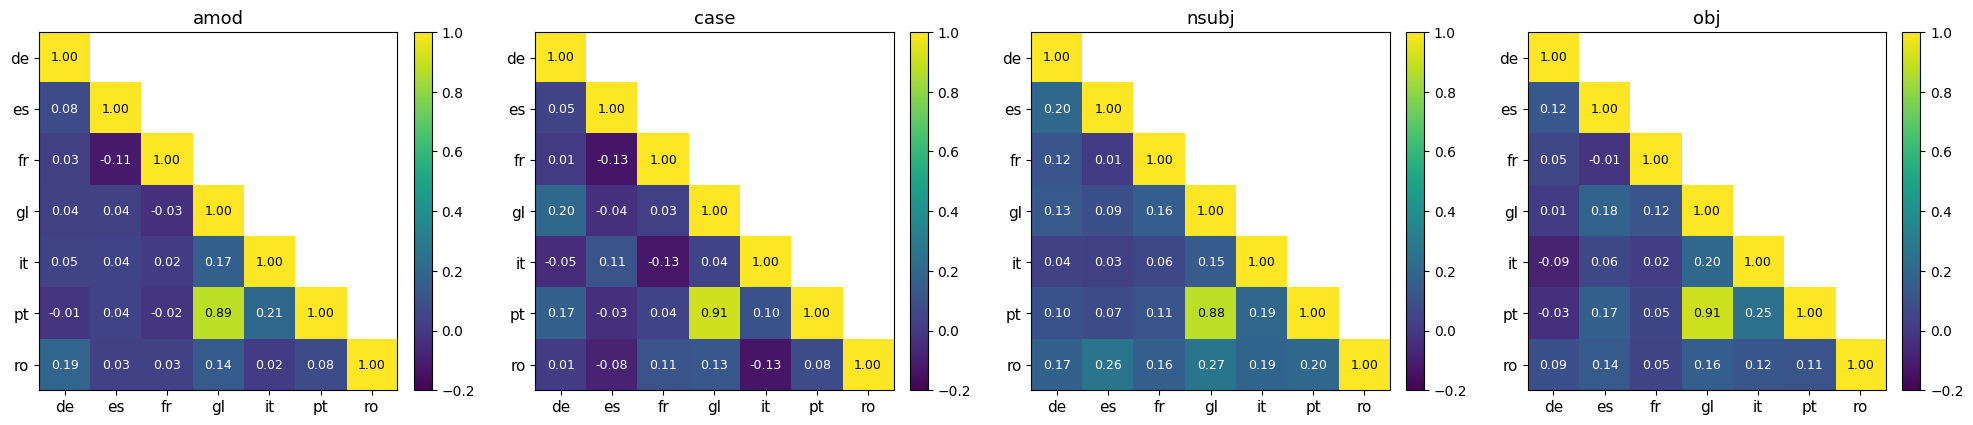

In [7]:
def lang_corr_matrix(frame, dep, mode="index"):
    n=len(LANGS); Mx=np.eye(n)
    for i,j in combinations(range(n),2):
        r=micro_pair(frame,LANGS[i],LANGS[j],mode)[dep]
        Mx[i,j]=Mx[j,i]=r
    return Mx

fig, axes = plt.subplots(1, len(DEPS), figsize=(5*len(DEPS),4.2))
if len(DEPS)==1: axes=[axes]
for ax,dep in zip(axes,DEPS):
    M=lang_corr_matrix(d,dep,"index")
    Mtri=np.ma.array(M, mask=np.triu(np.ones_like(M,bool),k=1))  # esconde triangulo superior
    im=ax.imshow(Mtri, vmin=-0.2, vmax=1.0, cmap="viridis")
    ax.set_xticks(range(len(LANGS))); ax.set_xticklabels(LANGS, fontsize=11)
    ax.set_yticks(range(len(LANGS))); ax.set_yticklabels(LANGS, fontsize=11)
    ax.set_title(dep, fontsize=13)
    for i in range(len(LANGS)):
        for j in range(i+1):
            ax.text(j,i,f"{M[i,j]:.2f}",ha="center",va="center",
                    color="white" if M[i,j]<0.6 else "black", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## 5. Diagnóstico do galego (responde à preocupação com treebank pequeno + fallback)

> *"The cap of 1000 sentences may be insufficient for Galician... uses the training split as a
> fallback for development. This may bias results for precisely the language that produces the most
> striking finding."*

Quantificamos os **arcos por relação** que cada língua de fato contribuiu (coluna `n_arcs`), para
mostrar o quão menor é o suporte empírico do galego — e sinalizamos onde o split `dev` veio do
fallback (`split == "train_fallback_dev"`, gravado pelo `resolve_split_path`).

In [8]:
piv = (d.groupby(["lang","deprel"])["n_arcs"].sum()
        .reset_index().pivot(index="lang", columns="deprel", values="n_arcs")
        .reindex(LANGS))
print("Arcos por lingua x relacao (direcao principal):")
print(piv.fillna(0).astype(int).to_string())

if "split" in df.columns:
    fb = df[df["split"].astype(str).str.contains("fallback", case=False, na=False)]
    if len(fb):
        print("\n[ATENCAO] splits com fallback train->dev detectados em:",
              sorted(fb["lang"].unique().tolist()))
    else:
        print("\nNenhum split de fallback no recorte atual (ou coluna sem o marcador).")

Arcos por lingua x relacao (direcao principal):
deprel    amod    case   nsubj     obj
lang                                  
de      114192  219600  163584   84096
es      286128  711360  277920  219456
fr       69840  188496   74736   49536
gl       82368  196416   64224   66960
it       84240  221904   62352   48384
pt      135936  486432  160560  147744
ro      151200  301968  106560   85392

[ATENCAO] splits com fallback train->dev detectados em: ['gl']


## 6. Robustez corpus vs. modelo (responde a aBFE) — requer execução com modelos

> *"Comparing the same model and language across two different sets of 1,000 sentences" e
> "comparing two different models of the same language on the same dataset."*

**Limitação atual do código:** `parse_conllu_sentences(max_sents)` pega sempre as **primeiras** N
sentenças, sem seed. Para "dois conjuntos de 1000 sentenças" é preciso amostrar aleatoriamente. A
função abaixo é um *drop-in* sobre `ud_attention_eval_core.parse_conllu_sentences` que adiciona
amostragem com `seed` (reporte a seed no artigo).

In [9]:
# 6a. Amostragem aleatoria reprodutivel (cole em ud_attention_eval_core.py)
import random
def parse_conllu_sentences_sampled(path, max_sents=None, seed=None):
    from ud_attention_eval_core import parse_conllu_sentences   # reaproveita o parser oficial
    sents = parse_conllu_sentences(path, max_sents=None)         # le TODAS
    if seed is not None and max_sents is not None and len(sents) > max_sents:
        rnd = random.Random(seed)
        sents = rnd.sample(sents, max_sents)
    elif max_sents is not None:
        sents = sents[:max_sents]
    return sents

print("Funcao de amostragem com seed definida. Use seeds distintas para gerar 2 subconjuntos.")

Funcao de amostragem com seed definida. Use seeds distintas para gerar 2 subconjuntos.


In [10]:
# 6b. Mesma LINGUA, DOIS MODELOS (usa os 'extras' ja cadastrados em lang_resources.HF_MODELS)
#     Ex.: pt -> neuralmind/bert-base-portuguese-cased  vs  neuralmind/bert-large-portuguese-cased
#          gl -> marcosgg/bert-base-gl-cased            vs  fpuentes/bert-galician
#
# Rode no terminal, um modelo por vez, via --model_mode manual_unico:
#
#   python src/run_ud_attention_eval.py --langs pt --splits test \
#       --model_mode manual_unico --manual_model neuralmind/bert-base-portuguese-cased \
#       --out_csv data/outputs/pt_base.csv
#   python src/run_ud_attention_eval.py --langs pt --splits test \
#       --model_mode manual_unico --manual_model neuralmind/bert-large-portuguese-cased \
#       --out_csv data/outputs/pt_large.csv
#
# ATENCAO: bert-large tem 24 camadas x 16 cabecas. Para comparar com base, restrinja a
# analise a uma sub-grade comum OU compare apenas no nivel macro (perfil por camada normalizado).
#
# Depois, carregue os dois CSVs e correlacione o MESMO modelo-lingua entre si:
def micro_between_files(csv_a, csv_b, dep, direction="head_to_dep"):
    a=pd.read_csv(csv_a); b=pd.read_csv(csv_b)
    a=a[a.direction==direction]; b=b[b.direction==direction]
    def vec(fr):
        la=int(fr.layer.max()); ha=int(fr.head.max()); v=np.zeros(la*ha)
        s=fr[fr.deprel==dep]
        for _,r in s.iterrows(): v[(int(r["layer"])-1)*ha+(int(r["head"])-1)]=r["mean_attention"]
        return v
    va, vb = vec(a), vec(b)
    n=min(len(va),len(vb))
    return spearman(va[:n], vb[:n])
print("micro_between_files() pronto para comparar 2 CSVs (mesma lingua, modelos diferentes).")

micro_between_files() pronto para comparar 2 CSVs (mesma lingua, modelos diferentes).


In [11]:
# 6c. MESMO MODELO, DOIS CORPORA (duas seeds de amostragem) -> usa 6a
# No run_one(), troque parse_conllu_sentences(...) por parse_conllu_sentences_sampled(..., seed=S)
# e rode duas vezes com S=13 e S=42, salvando pt_seed13.csv e pt_seed42.csv. Depois:
#   r = micro_between_files("data/outputs/pt_seed13.csv","data/outputs/pt_seed42.csv","nsubj")
# Um r alto = robustez ao corpus; r baixo = a metrica depende muito da amostra.
print("Plano 6c documentado. Use a mesma micro_between_files() entre as duas seeds.")

Plano 6c documentado. Use a mesma micro_between_files() entre as duas seeds.


## 7. Análise monolíngue primeiro (responde ao objetivo da Seção 4.5)

> *"Why not perform a monolingual analysis first, to determine if the models actually encode
> syntactic relations in a specific region of the architecture and then proceed to a cross-lingual
> analysis?"*

Para cada modelo/relação medimos **onde** a atenção se concentra: a posição (camada, cabeça) de pico
e a fração da massa de atenção nas top-k posições. Só então faz sentido perguntar se essas regiões
coincidem entre línguas.

In [12]:
def concentration(frame, lang, dep, k=5):
    M=mat12(frame,lang,dep); flat=M.flatten()
    total=flat.sum()
    if total<=0: return dict(lang=lang, deprel=dep, pico_camada=np.nan, pico_cabeca=np.nan, massa_top=np.nan)
    pk=int(np.argmax(flat)); lk,hk=pk//H+1, pk%H+1
    topk_mass=np.sort(flat)[::-1][:k].sum()/total
    return dict(lang=lang, deprel=dep, pico_camada=lk, pico_cabeca=hk, massa_top=round(topk_mass,3))

recs=[concentration(d,lg,dep) for dep in DEPS for lg in LANGS]
mono=pd.DataFrame(recs)
print("Concentracao intra-modelo (pico e massa nas top-5 posicoes):")
print(mono.to_string(index=False))

print("\nDispersao da camada de pico entre linguas (alto = regiao NAO coincide):")
print(mono.groupby("deprel")["pico_camada"].agg(["min","max","std"]).round(2).to_string())

Concentracao intra-modelo (pico e massa nas top-5 posicoes):
lang deprel  pico_camada  pico_cabeca  massa_top
  de   amod            2            3      0.221
  es   amod            6            8      0.172
  fr   amod            5            4      0.273
  gl   amod            2            3      0.263
  it   amod            8           11      0.185
  pt   amod            7           10      0.216
  ro   amod            2            4      0.247
  de   case           11            5      0.207
  es   case            8            2      0.209
  fr   case            3            2      0.291
  gl   case            6           11      0.273
  it   case            8            6      0.219
  pt   case            5           11      0.269
  ro   case            4            3      0.334
  de  nsubj           10           10      0.122
  es  nsubj            6            4      0.152
  fr  nsubj            3            2      0.226
  gl  nsubj            6           11      0.198
  it  ns

## 8. Método de agregação (responde à pergunta da Seção 3.4)

> *"the attention between two UD tokens is obtained by aggregation over the corresponding subword
> spans: what aggregation method is used?"*

No código (`ud_attention_eval_core.mean_attention_between_spans`) a agregação é a **média aritmética
simples** da submatriz de atenção subword×subword:

```python
sub = attn[a0:a1, b0:b1]   # bloco span_head x span_dep
return float(sub.mean())   # media aritmetica simples
```

Sugestão de frase para a 3.4: *"A atenção entre dois tokens UD é a média aritmética das atenções
entre todos os pares de subwords correspondentes (média simples sobre o bloco span_head × span_dep);
não se aplica ponderação por posição nem max-pooling."* Como robustez, vale reportar uma variante com
`max` no lugar de `mean` para mostrar que o padrão não depende dessa escolha.

---
### Checklist de uso

1. Aponte `CSV_PATH` para seu CSV agregado e rode as Seções 1–5, 7, 8.
2. A **Seção 1** é a de maior impacto: rode e decida a redação da dissociação micro/macro pelos resultados de `matched_loo`.
3. A **Seção 6** exige rodar o pipeline com modelos; siga os comandos comentados (lembre da grade diferente do bert-large).
4. Reporte no artigo: seeds de amostragem, método de matching usado, e os números `index` vs `matched_loo` lado a lado.